In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import io as sio
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim


DATA LOADING AND VISUALIZATION

Dataset Info
Data shape: (145, 145, 200) (Height, Width, Spectral Bands)
Ground truth shape: (145, 145) (Height, Width)
Number of spectral bands: 200
Image dimensions: 145 x 145
Unique classes in ground truth: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Total pixels: 21025


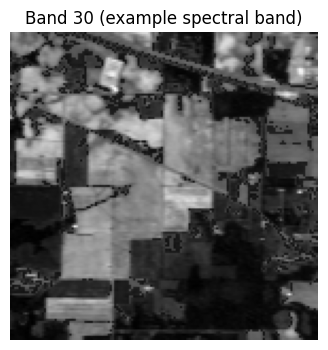

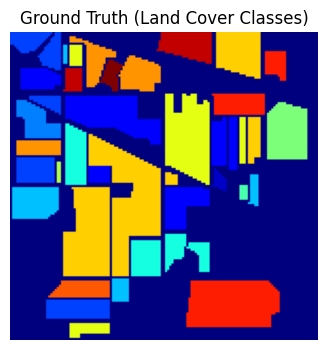

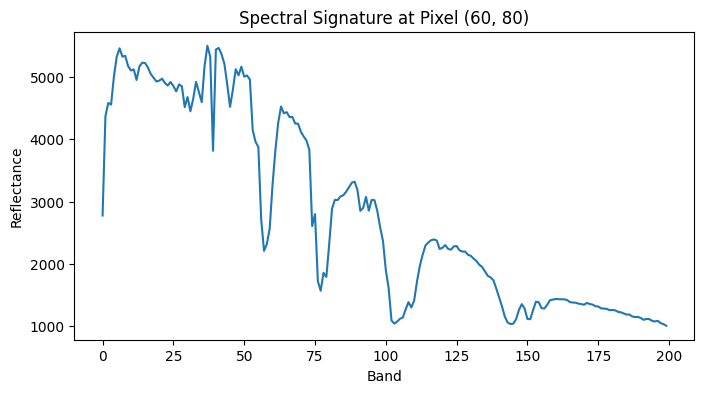

• 16 land-cover classes in ground truth
• Data type: uint16


In [2]:

data = sio.loadmat('Indian_pines_corrected.mat').get('indian_pines_corrected')
gt = sio.loadmat('Indian_pines_gt.mat').get('indian_pines_gt')

print("Dataset Info")
print(f"Data shape: {data.shape} (Height, Width, Spectral Bands)")
print(f"Ground truth shape: {gt.shape} (Height, Width)")
print(f"Number of spectral bands: {data.shape[2]}")
print(f"Image dimensions: {data.shape[0]} x {data.shape[1]}")
print(f"Unique classes in ground truth: {np.unique(gt)}")
print(f"Total pixels: {data.shape[0] * data.shape[1]}")

# Show a single spectral band as a grayscale image
plt.figure(figsize=(6, 4))
plt.imshow(data[:, :, 30], cmap='gray')
plt.title('Band 30 (example spectral band)')
plt.axis('off')
plt.show()

# Show the ground truth map
plt.figure(figsize=(6, 4))
plt.imshow(gt, cmap='jet')
plt.title('Ground Truth (Land Cover Classes)')
plt.axis('off')
plt.show()


row, col = 60, 80
plt.figure(figsize=(8, 4))
plt.plot(data[row, col, :])
plt.title(f'Spectral Signature at Pixel ({row}, {col})')
plt.xlabel('Band')
plt.ylabel('Reflectance')
plt.show()

print("• 16 land-cover classes in ground truth")
print("• Data type:", data.dtype)



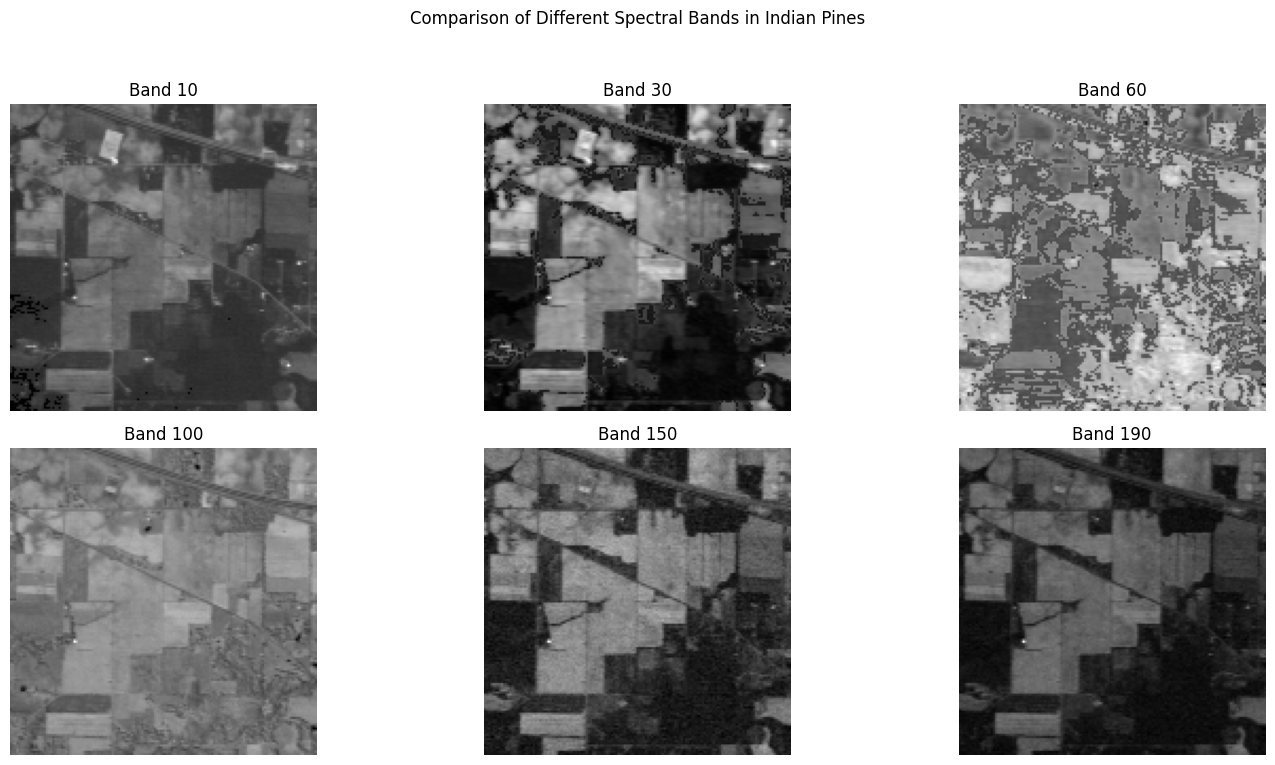

In [3]:
bands_to_show = [10, 30, 60, 100, 150, 190]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, band in enumerate(bands_to_show):
    ax = axes[idx // 3, idx % 3]
    ax.imshow(data[:, :, band], cmap='gray')
    ax.set_title(f'Band {band}')
    ax.axis('off')
plt.suptitle('Comparison of Different Spectral Bands in Indian Pines')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [4]:
PCA

sklearn.decomposition._pca.PCA

In [5]:
h, w, bands = data.shape
X = data.reshape(-1, bands)
y = gt.flatten()
mask = y > 0
X = X[mask]
y = y[mask] - 1

# PCA to reduce bands (spectral dimension)
pca_bands = 30
pca = PCA(n_components=pca_bands)
X_pca = pca.fit_transform(X)


PATCH EXTRACTION

In [6]:
def extract_patches(data, gt, patch_size=5, pca_bands=30):
    h, w, _ = data.shape
    margin = patch_size // 2
    patches, labels = [], []
    pca = PCA(n_components=pca_bands)
    data_pca = pca.fit_transform(data.reshape(-1, data.shape[2])).reshape(h, w, pca_bands)
    for i in range(margin, h - margin):
        for j in range(margin, w - margin):
            label = gt[i, j]
            if label > 0:
                cube = data_pca[i-margin:i+margin+1, j-margin:j+margin+1, :]
                patches.append(cube)
                labels.append(label - 1)
    return np.array(patches), np.array(labels)

patches, labels = extract_patches(data, gt, patch_size=5, pca_bands=30)


TRAIN TEST 

In [7]:

# Each patch: (patch_size, patch_size, pca_bands)
# Flatten spatial, so each patch is (patch_size*patch_size, pca_bands)
patches_flat = patches.reshape(patches.shape[0], -1, patches.shape[-1])
num_classes = len(np.unique(labels))

X_train, X_test, y_train, y_test = train_test_split(
    patches_flat, labels, test_size=0.3, random_state=42, stratify=labels
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


D2BERT MODEL (TRANSFORMER)

In [8]:

class D2BERT(nn.Module):
    def __init__(self, seq_len, feature_dim, d_model, num_classes, num_layers=4, num_heads=4):
        super().__init__()
        self.embedding = nn.Linear(feature_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)
    def forward(self, x):
        x = self.embedding(x) + self.pos_embed  # (batch, seq, d_model)
        x = x.permute(1, 0, 2)  # (seq, batch, d_model)
        x = self.transformer(x)
        x = x.mean(dim=0)  # (batch, d_model)
        return self.classifier(x)

seq_len = patches_flat.shape[1]
feature_dim = patches_flat.shape[2]
model = D2BERT(seq_len=seq_len, feature_dim=feature_dim, d_model=64, num_classes=num_classes)


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

TRAINING

In [10]:


epochs = 20
batch_size = 128

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    for i in range(0, X_train.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")




Epoch 5/20, Loss: 0.1621
Epoch 10/20, Loss: 0.0123
Epoch 15/20, Loss: 0.1236
Epoch 20/20, Loss: 0.0036


EVALUATION

In [11]:
model.eval()
with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean().item()
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 98.88%


In [12]:
# Parameters (should match your training setup)
patch_size = 5
pca_bands = 30
margin = patch_size // 2

# Load data and PCA

# Use the same PCA object as in training
# If you didn't save it, re-fit on the whole image for demonstration, but for real use, save/load the trained PCA
from sklearn.decomposition import PCA
h, w, bands = data.shape
X_full = data.reshape(-1, bands)
pca = PCA(n_components=pca_bands)
pca.fit(X_full)  # In practice, use the PCA fitted during training

# Choose a pixel
row, col = 70, 70

# Extract patch
cube = data[
    row - margin : row + margin + 1,
    col - margin : col + margin + 1,
    :
]  # shape: (patch_size, patch_size, bands)

# Apply PCA to each pixel in the patch
cube_flat = cube.reshape(-1, bands)
cube_pca = pca.transform(cube_flat)
patch = cube_pca.reshape(patch_size * patch_size, -1)  # (sequence_length, pca_bands)

# Convert to tensor and add batch dimension
patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0)  # (1, seq_len, pca_bands)


In [13]:
model.eval()
with torch.no_grad():
    output = model(patch_tensor)
    pred_class = output.argmax(dim=1).item()
print(f"Predicted class for pixel ({row}, {col}): {pred_class + 1}")


Predicted class for pixel (70, 70): 11


In [14]:
true_class = gt[row, col]
print(f"Ground truth class for pixel ({row}, {col}): {true_class}")


Ground truth class for pixel (70, 70): 11


In [15]:


patch_size = 5
pca_bands = 30
margin = patch_size // 2

h, w, bands = data.shape
pred_map = np.zeros((h, w), dtype=int)


for i in range(margin, h - margin):
    for j in range(margin, w - margin):
        # Skip background pixels if needed
        if gt[i, j] == 0:
            continue
        cube = data[i-margin:i+margin+1, j-margin:j+margin+1, :]
        cube_flat = cube.reshape(-1, bands)
        cube_pca = pca.transform(cube_flat)
        patch = cube_pca.reshape(patch_size * patch_size, -1)
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0)
        model.eval()
        with torch.no_grad():
            output = model(patch_tensor)
            pred_class = output.argmax(dim=1).item()
        pred_map[i, j] = pred_class + 1  # Add 1 if your classes start from 1


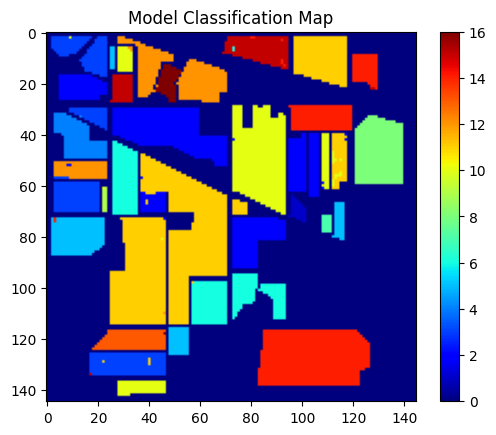

In [16]:

plt.imshow(pred_map, cmap='jet')
plt.title('Model Classification Map')
plt.colorbar()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_1584\1508332341.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


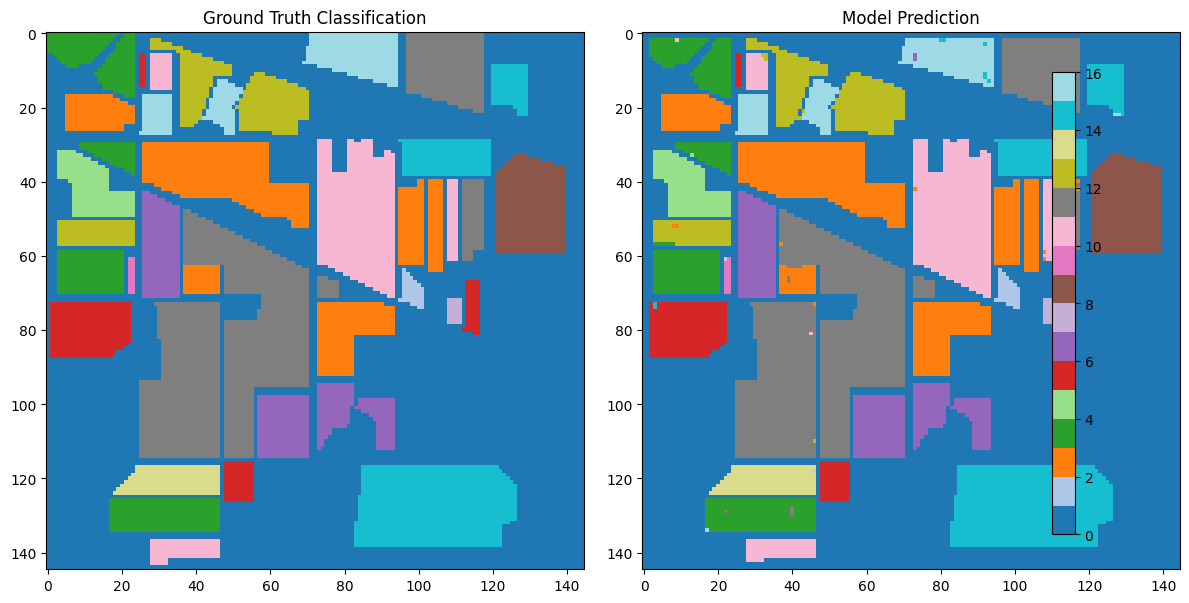

In [17]:


# pred_map: (H, W) array of predicted class indices
# gt: (H, W) array of ground truth class indices

cmap = plt.get_cmap('tab20', np.max(gt))  # or use 'jet' or 'parula' for more classes

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(gt, cmap=cmap, vmin=0, vmax=np.max(gt))
axs[0].set_title('Ground Truth Classification')
axs[1].imshow(pred_map, cmap=cmap, vmin=0, vmax=np.max(gt))
axs[1].set_title('Model Prediction')
plt.colorbar(axs[1].images[0], ax=axs, orientation='vertical', fraction=0.025)
plt.tight_layout()
plt.show()


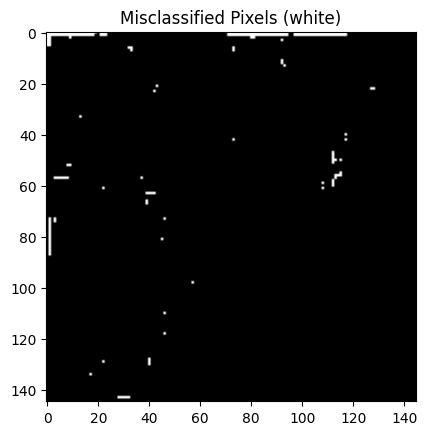

In [18]:
diff = (gt != pred_map) & (gt != 0)  # Ignore unlabeled pixels (often 0)
plt.imshow(diff, cmap='gray')
plt.title('Misclassified Pixels (white)')
plt.show()


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Flatten and ignore unlabeled pixels (usually label 0)
mask = gt.flatten() > 0
y_true = gt.flatten()[mask]
y_pred = pred_map.flatten()[mask]

print("Overall Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


Overall Accuracy: 0.977753927212411

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     1.0000    1.0000    1.0000        46
           2     0.9937    0.9958    0.9948      1428
           3     0.9923    0.9277    0.9589       830
           4     0.9958    1.0000    0.9979       237
           5     1.0000    0.9648    0.9821       483
           6     0.9973    0.9986    0.9979       730
           7     1.0000    1.0000    1.0000        28
           8     1.0000    1.0000    1.0000       478
           9     1.0000    0.9500    0.9744        20
          10     0.9816    0.9887    0.9851       972
          11     0.9954    0.9743    0.9848      2455
          12     0.9898    0.9865    0.9882       593
          13     1.0000    0.9951    0.9976       205
          14     0.9937    0.9984    0.9961      1265
          15     0.9910    0.8549    0.9179       386
          16     0.9

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0   46    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0 1422    0    0    0    0    0    0    0    0    6    0    0
     0    0    0]
 [  53    0    0  770    1    0    0    0    0    0    1    4    0    0
     0    1    0]
 [   0    0    0    0  237    0    0    0    0    0    0    0    0    0
     0    0    0]
 [  15    0    0    0    0  466    0    0    0    0    0    0    0    0
     2    0    0]
 [   0    0    0    0    0    0  729    0    0    0    0    1    0    0
     0    0    0]
 [   0    0    0    0    0    0    0   28    0    0    0    0    0    0
     0    0    0]
 [   0    0    0    0    0    0    0    0  478    0    0    0    0    0
     0    0    0]
 [   0    0    0    0    0    0    0    0    0   19    1    0    0    0
     0    0    0]
 [   5    0    3    0    0    0    0    0    0    0  961    0    3    0
     0   

In [21]:
import numpy as np

total_samples = np.sum(cm)
correct_predictions = np.trace(cm) 
wrong_predictions = total_samples - correct_predictions

print(f"Total samples: {total_samples}")
print(f"Correct predictions: {correct_predictions}")
print(f"Wrong predictions: {wrong_predictions}")
print(f"Accuracy: {correct_predictions / total_samples:.4f}")


Total samples: 10249
Correct predictions: 10021
Wrong predictions: 228
Accuracy: 0.9778


Test Accuracy: 98.88%

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        14
           1     0.9885    0.9977    0.9930       429
           2     0.9829    0.9871    0.9850       233
           3     1.0000    1.0000    1.0000        71
           4     1.0000    0.9929    0.9964       140
           5     0.9954    0.9954    0.9954       219
           6     1.0000    1.0000    1.0000         8
           7     1.0000    1.0000    1.0000       143
           8     1.0000    0.8333    0.9091         6
           9     0.9664    0.9931    0.9796       290
          10     0.9944    0.9820    0.9882       724
          11     0.9830    0.9719    0.9774       178
          12     1.0000    1.0000    1.0000        62
          13     0.9895    0.9947    0.9921       380
          14     0.9700    0.9604    0.9652       101
          15     1.0000    0.9643    0.9818        28

    accuracy                     

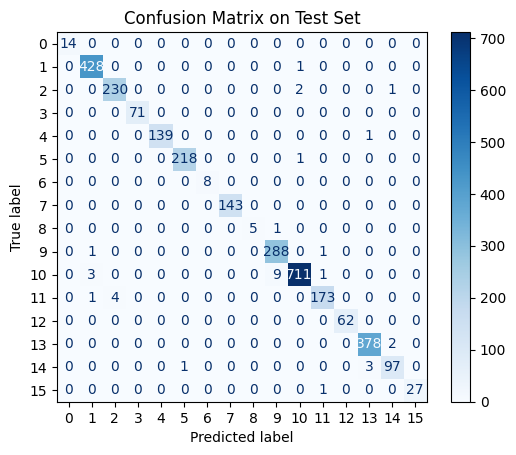

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming y_test are the true labels from train_test_split
# preds are the predicted labels from your model for X_test

# 1. Calculate accuracy
test_accuracy = accuracy_score(y_test, preds)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# 2. Print classification report
print("\nClassification Report:\n", classification_report(y_test, preds, digits=4))

# 3. Compute and print confusion matrix
cm = confusion_matrix(y_test, preds)
print("\nConfusion Matrix:\n", cm)

# 4. Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()


# test set predictions v/s ground truth

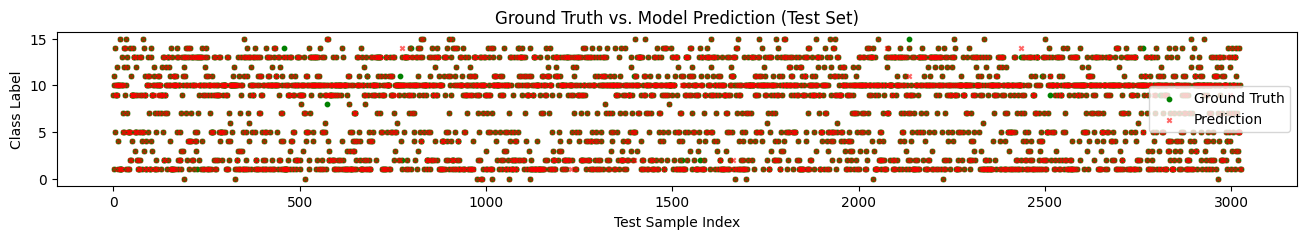

In [23]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(y_test))
plt.figure(figsize=(16, 2))
plt.scatter(x, y_test, c='g', label='Ground Truth', s=10)
plt.scatter(x, preds, c='r', marker='x', label='Prediction', s=10, alpha=0.6)
plt.legend()
plt.title('Ground Truth vs. Model Prediction (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Class Label')
plt.show()


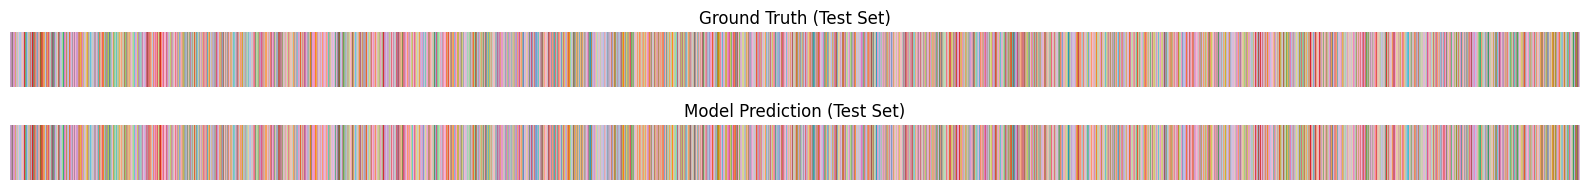

In [24]:
import matplotlib.pyplot as plt
import numpy as np

y_test_np = y_test.cpu().numpy() if hasattr(y_test, 'cpu') else np.array(y_test)
preds_np = preds.cpu().numpy() if hasattr(preds, 'cpu') else np.array(preds)

fig, axs = plt.subplots(2, 1, figsize=(16, 2), sharex=True)

axs[0].imshow([y_test_np], aspect='auto', cmap='tab20', vmin=0, vmax=np.max(y_test_np))
axs[0].set_title('Ground Truth (Test Set)')
axs[0].axis('off')

axs[1].imshow([preds_np], aspect='auto', cmap='tab20', vmin=0, vmax=np.max(y_test_np))
axs[1].set_title('Model Prediction (Test Set)')
axs[1].axis('off')

plt.tight_layout()
plt.show()
